In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.datasets import cifar10



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# ==========================================================
# Load CIFAR-10 Dataset
# ==========================================================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Data Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print()

print("Testing Data Shape :", X_test.shape)
print("Testing Labels Shape :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3288s 19us/step


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training Data Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)

Testing Data Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 1)


In [3]:
# ==========================================================
# Dataset Information
# ==========================================================

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print()

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

print()

print("Image Height :", X_train.shape[1])
print("Image Width  :", X_train.shape[2])
print("Color Channels :", X_train.shape[3])

print()

print("Number of Classes :", len(np.unique(y_train)))

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)

Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)

Image Height : 32
Image Width  : 32
Color Channels : 3

Number of Classes : 10


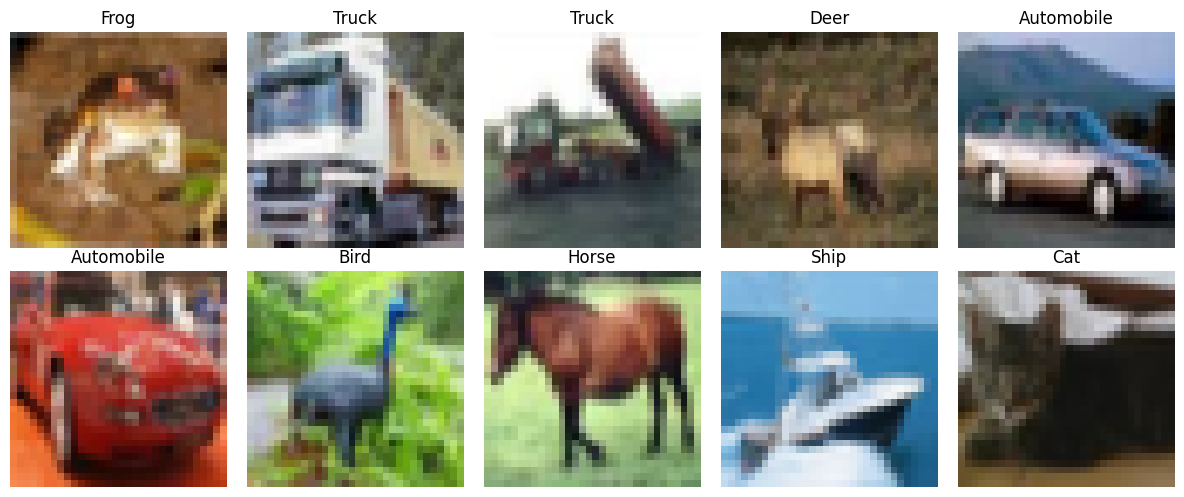

In [5]:
# ==========================================================
# Display Sample Images
# ==========================================================

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [6]:
# ==========================================================
# Normalize the Dataset
# ==========================================================

X_train = X_train.astype("float32") / 255.0

X_test = X_test.astype("float32") / 255.0

print("Maximum Pixel Value :", X_train.max())
print("Minimum Pixel Value :", X_train.min())

Maximum Pixel Value : 1.0
Minimum Pixel Value : 0.0


In [7]:
# ==========================================================
# Dataset Shape after Normalization
# ==========================================================

print("Training Data :", X_train.shape)
print("Training Labels :", y_train.shape)

print()

print("Testing Data :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Data : (50000, 32, 32, 3)
Training Labels : (50000, 1)

Testing Data : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


In [8]:
# ==========================================================
# Build Convolutional Neural Network (CNN)
# ==========================================================

model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(32,32,3)
    ),

    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(10, activation="softmax")

])

model.summary()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ==========================================================
# Compile CNN Model
# ==========================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
# ==========================================================
# Train CNN Model
# ==========================================================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.4534 - loss: 1.5151 - val_accuracy: 0.5414 - val_loss: 1.2974
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.5874 - loss: 1.1715 - val_accuracy: 0.6076 - val_loss: 1.1101
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.6365 - loss: 1.0400 - val_accuracy: 0.6354 - val_loss: 1.0267
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.6699 - loss: 0.9496 - val_accuracy: 0.6656 - val_loss: 0.9785
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.6954 - loss: 0.8788 - val_accuracy: 0.6658 - val_loss: 0.9663
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.7176 - loss: 0.8137 - val_accuracy: 0.6739 - val_loss: 0.9553
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.7353 - loss: 0.7626 - val_accuracy: 0.6873 - val_loss: 0.9356
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.7509 -

In [12]:
# ==========================================================
# Model Evaluation
# ==========================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", round(test_accuracy * 100, 2), "%")
print("Test Loss :", round(test_loss, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6913 - loss: 0.9537
Test Accuracy : 69.13 %
Test Loss : 0.9537


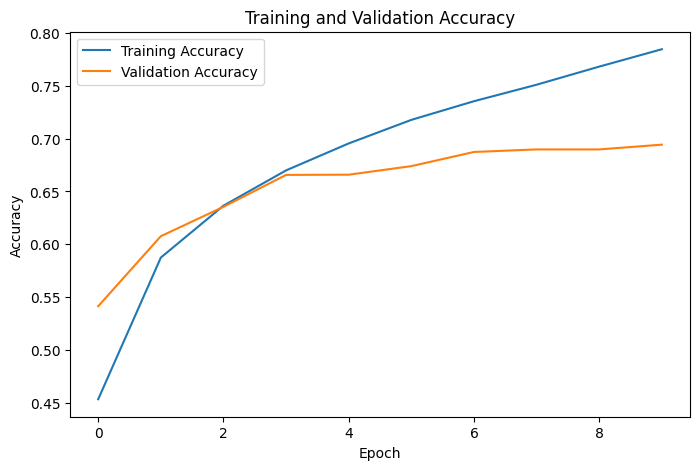

In [13]:
# ==========================================================
# Training & Validation Accuracy
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

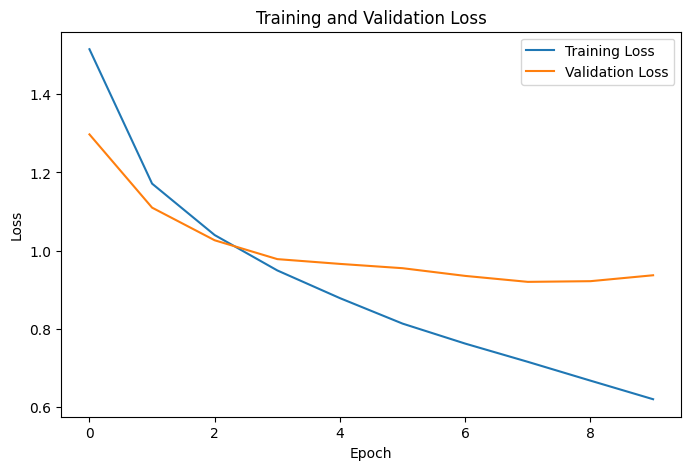

In [14]:
# ==========================================================
# Training & Validation Loss
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [15]:
# ==========================================================
# Predict Test Images
# ==========================================================

predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Prediction Completed!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step
Prediction Completed!


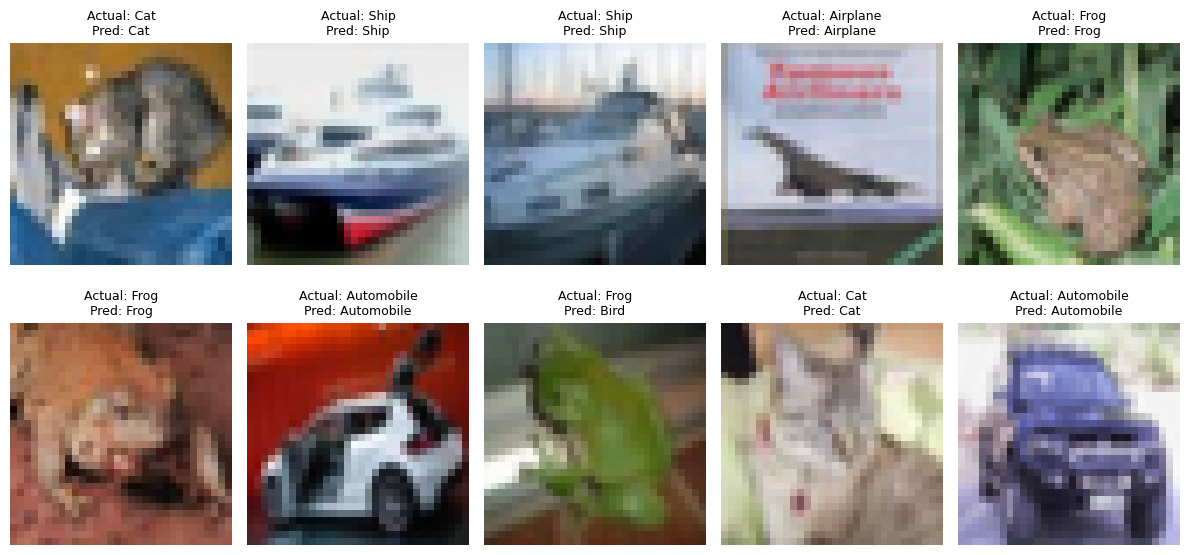

In [16]:
# ==========================================================
# Display Sample Predictions
# ==========================================================

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i])

    plt.title(
        f"Actual: {class_names[y_test[i][0]]}\nPred: {class_names[predicted_labels[i]]}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [17]:
# ==========================================================
# Prediction Results
# ==========================================================

for i in range(10):

    print(
        f"Image {i+1}: Actual = {class_names[y_test[i][0]]} | Predicted = {class_names[predicted_labels[i]]}"
    )

Image 1: Actual = Cat | Predicted = Cat
Image 2: Actual = Ship | Predicted = Ship
Image 3: Actual = Ship | Predicted = Ship
Image 4: Actual = Airplane | Predicted = Airplane
Image 5: Actual = Frog | Predicted = Frog
Image 6: Actual = Frog | Predicted = Frog
Image 7: Actual = Automobile | Predicted = Automobile
Image 8: Actual = Frog | Predicted = Bird
Image 9: Actual = Cat | Predicted = Cat
Image 10: Actual = Automobile | Predicted = Automobile


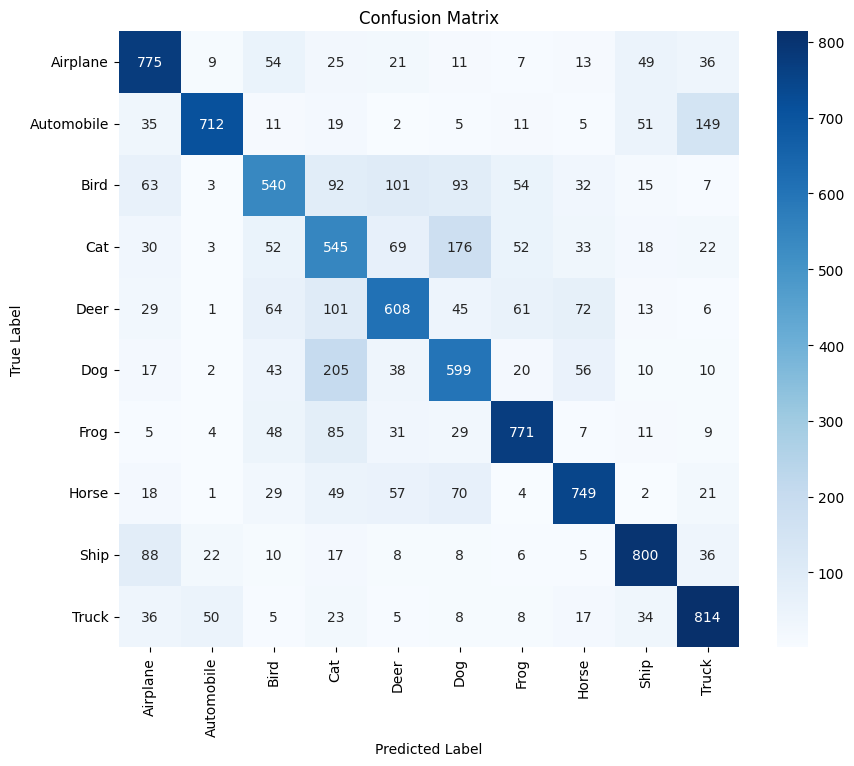

In [18]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

In [19]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.71      0.78      0.74      1000
  Automobile       0.88      0.71      0.79      1000
        Bird       0.63      0.54      0.58      1000
         Cat       0.47      0.55      0.50      1000
        Deer       0.65      0.61      0.63      1000
         Dog       0.57      0.60      0.59      1000
        Frog       0.78      0.77      0.77      1000
       Horse       0.76      0.75      0.75      1000
        Ship       0.80      0.80      0.80      1000
       Truck       0.73      0.81      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



In [20]:
# ==========================================================
# Save CNN Model
# ==========================================================

import os

os.makedirs("model", exist_ok=True)

model.save("model/cifar10_cnn.keras")

print("CNN model saved successfully!")

CNN model saved successfully!
